# Can two library inventories be combined with one field mapping?

[Clearwater library locations](https://gis.myclearwater.com/arcgis/rest/services/ArcGISMapServices/ClearwaterServicesApp_WGS84/MapServer/1) and [Hillsborough library locations](https://services.arcgis.com/apTfC6SUmnNfnxuF/arcgis/rest/services/Libraries_hc/FeatureServer/0) describe different service areas with different field names. This notebook explores the schema and missing values needed to make a small combined directory. It does not compare access, quality, or service levels.


## 1. Retrieve two complete checked layers

Each result carries its own provenance. Save it before combining rows because ordinary data-frame operations may drop attributes.


In [1]:
library(tampaBayOpenData)

clearwater <- tbod_get_dataset(
  "clearwater-libraries",
  fields = c("OBJECTID", "NAME", "FULLADDR", "OWNER"), total_timeout = 120
)
hillsborough <- tbod_get_dataset(
  "hillsborough-libraries",
  fields = c("OBJECTID", "Name_Full", "Name_Label", "Address", "City", "Type"),
  total_timeout = 120
)
sources <- lapply(list(clearwater, hillsborough), tbod_provenance)
stopifnot(all(vapply(sources, function(x) isTRUE(x$complete), logical(1))))
print(data.frame(source = c("Clearwater", "Hillsborough"),
                 records = c(nrow(clearwater), nrow(hillsborough)),
                 retrieved_at = vapply(sources, function(x) as.character(x$retrieved_at), "")))


        source records               retrieved_at
1   Clearwater       5 2026-10-06 22:40:35.923273
2 Hillsborough      31 2026-10-06 22:40:36.702593


## 2. Measure which source fields actually carry a name

A field existing in the schema does not mean it is filled in the live records. Hillsborough offers both `Name_Full` and `Name_Label`; we inspect them before choosing a fallback.


                    field filled records percent_filled
1         Clearwater NAME      5       5            100
2  Hillsborough Name_Full      0      31              0
3 Hillsborough Name_Label     31      31            100


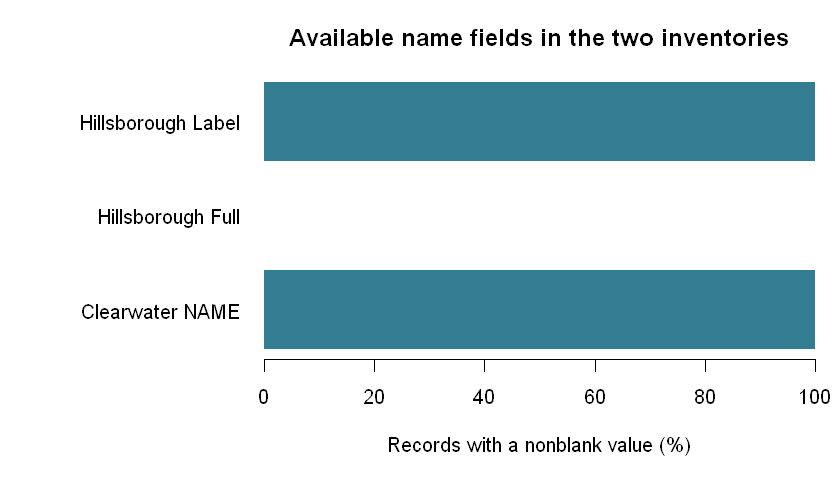

In [2]:
present <- function(x) !is.na(x) & nzchar(trimws(as.character(x)))
name_fields <- data.frame(
  field = c("Clearwater NAME", "Hillsborough Name_Full", "Hillsborough Name_Label"),
  filled = c(sum(present(clearwater$NAME)), sum(present(hillsborough$Name_Full)),
             sum(present(hillsborough$Name_Label))),
  records = c(nrow(clearwater), nrow(hillsborough), nrow(hillsborough))
)
name_fields$percent_filled <- round(100 * name_fields$filled / name_fields$records, 1)
print(name_fields)

options(repr.plot.width = 7, repr.plot.height = 4)
previous <- par(mar = c(5, 11, 3, 1))
barplot(name_fields$percent_filled,
        names.arg = c("Clearwater NAME", "Hillsborough Full", "Hillsborough Label"),
        horiz = TRUE, las = 1, xlim = c(0, 100), col = "#347c92", border = NA,
        xlab = "Records with a nonblank value (%)",
        main = "Available name fields in the two inventories")
par(previous)


## 3. Make a small, traceable directory

The mapping keeps the publisher and source object ID. Missing Hillsborough full names fall back to the label field. We keep each agency's own address text without geocoding or merging likely duplicate facilities.


In [3]:
hill_name <- as.character(hillsborough$Name_Full)
fallback <- !present(hill_name)
hill_name[fallback] <- as.character(hillsborough$Name_Label[fallback])
directory <- rbind(
  data.frame(publisher = "Clearwater", object_id = clearwater$OBJECTID,
             name = as.character(clearwater$NAME), address = as.character(clearwater$FULLADDR)),
  data.frame(publisher = "Hillsborough", object_id = hillsborough$OBJECTID,
             name = hill_name, address = as.character(hillsborough$Address))
)
print(data.frame(records = nrow(directory), missing_name = sum(!present(directory$name)),
                 missing_address = sum(!present(directory$address)),
                 used_hillsborough_name_fallback = sum(fallback)))
print(utils::head(directory, 8))


  records missing_name missing_address used_hillsborough_name_fallback
1      36            0               0                              31


     publisher object_id                               name
1   Clearwater         4                       East Library
2   Clearwater         5                       Main Library
3   Clearwater         6                      Beach Library
4   Clearwater         7                Countryside Library
5   Clearwater         8               N. Greenwood Library
6 Hillsborough       107                        78th Street
7 Hillsborough       108 Arthenia L. Joyner University Area
8 Hillsborough       109                       Austin Davis
                                 address
1      2251 Drew St Clearwater, FL 33765
2 100 N Osceola Ave Clearwater, FL 33755
3  69 Bay Esplanade Clearwater, FL 33767
4       2741 SR 580 Clearwater, FL 33761
5  905 N MLK Jr Ave Clearwater, FL 33755
6                     7625 Palm River Rd
7                        13619 N 22nd St
8                         17808 Wayne Rd


## What this means

The two layers can be placed in a common *directory* shape, but they are separate publisher inventories. Counts cannot be read as a comparison of library access, and this mapping makes no claim that the publisher records represent the same facility type or update schedule.
